<h1 style="text-align: center; color: purple;">Healthcare Premium Prediction Project (Regression)</h1>

<h2 style="text-align: center; color: orange;">Minimum Viable Product (MVP) Development</h2>

In [190]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

### **Read data from excel files**

In [191]:
df = pd.read_excel("data/dataset.xlsx")

In [192]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [193]:
df.tail(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490
49999,48,Female,Southwest,Married,3,Normal,Occasional,Self-Employed,<10L,7,Diabetes,Silver,19730


In [194]:
df.shape

(50000, 13)

In [195]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [196]:
df.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


### **Data Cleaning & Exploratory Data Analysis**

#### **Handling Missing Values**

In [197]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [198]:
df.dropna(inplace=True)

In [199]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

#### **Handling Duplicates**

In [200]:
df.duplicated().sum()

np.int64(0)

In [201]:
df.drop_duplicates(inplace=True)

In [202]:
df.duplicated().sum()

np.int64(0)

In [203]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


#### **Data Cleaning: number_of_dependants**

In [204]:
df[df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-3, -1])

The `number_of_dependants` feature contains negative values, which are likely due to data entry or recording errors. Since the number of dependants cannot be negative in a real-world scenario, these values will be converted to their corresponding positive values as part of the data cleaning process.

In [205]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

In [206]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.717284,23.021150,15766.810189
std,15.000378,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


### **1. Numeric Columns**

#### **Univariate Analysis: Numeric Columns**

**Box plots for numeric columns**

In [207]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

In [208]:
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

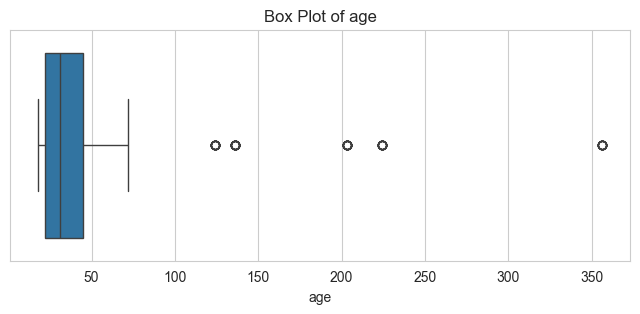

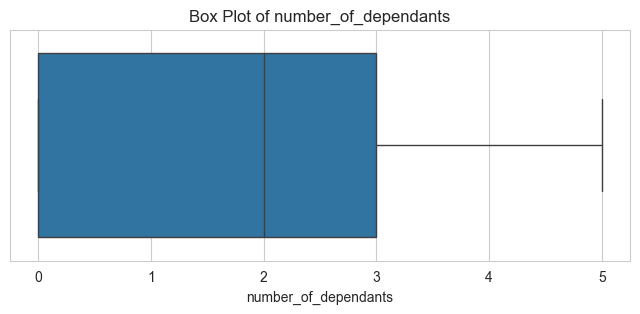

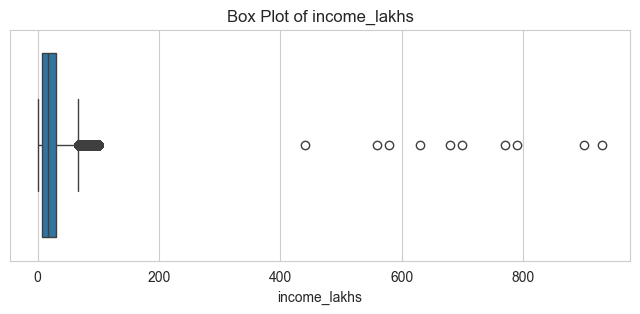

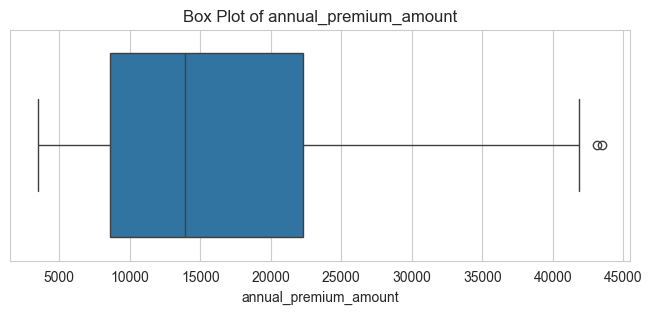

In [209]:
for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

#### **Outlier Treatment: Age Column**

In [210]:
df[df['age']>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [211]:
df1 = df[df.age<=100]

In [212]:
df1.age.describe()

count    49918.000000
mean        34.401839
std         13.681600
min         18.000000
25%         22.000000
50%         31.000000
75%         45.000000
max         72.000000
Name: age, dtype: float64

#### **Outlier Treatment: Income Column**

In [213]:
def calculate_iqr_bounds(column):
    q1, q3 = column.quantile([0.25, 0.75])
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

lower_bound, upper_bound = calculate_iqr_bounds(df1['income_lakhs'])
lower_bound, upper_bound

(-29.0, 67.0)

In [214]:
df1[df1['income_lakhs'] > upper_bound].shape

(3559, 13)

Using the IQR method would remove a significant number of legitimate observations. Therefore, after consultation with business stakeholders, a quantile-based approach was chosen to handle outliers while preserving valuable data.

In [215]:
quantile_thresold = df1.income_lakhs.quantile(0.999)

In [216]:
quantile_thresold

np.float64(100.0)

In [217]:
df1[df1.income_lakhs>quantile_thresold].shape

(10, 13)

In [218]:
df2 = df1[df1.income_lakhs<=quantile_thresold].copy()

In [219]:
df2.shape

(49908, 13)

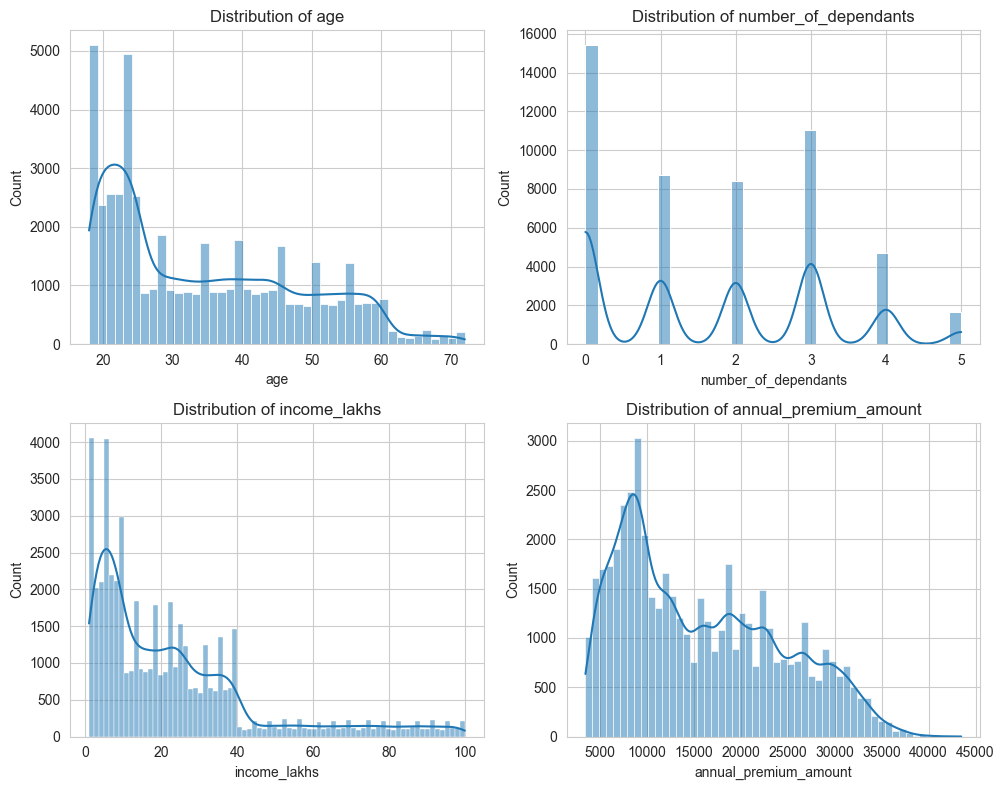

In [220]:
# Visualize the distribution of numerical features
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for index, column in enumerate(numeric_columns):
    ax = axes[index // 2, index % 2]
    sns.histplot(df2[column], kde=True, ax=ax)
    ax.set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

In [221]:
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


#### **Bivariate Analysis: Numeric Columns**

In [222]:
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

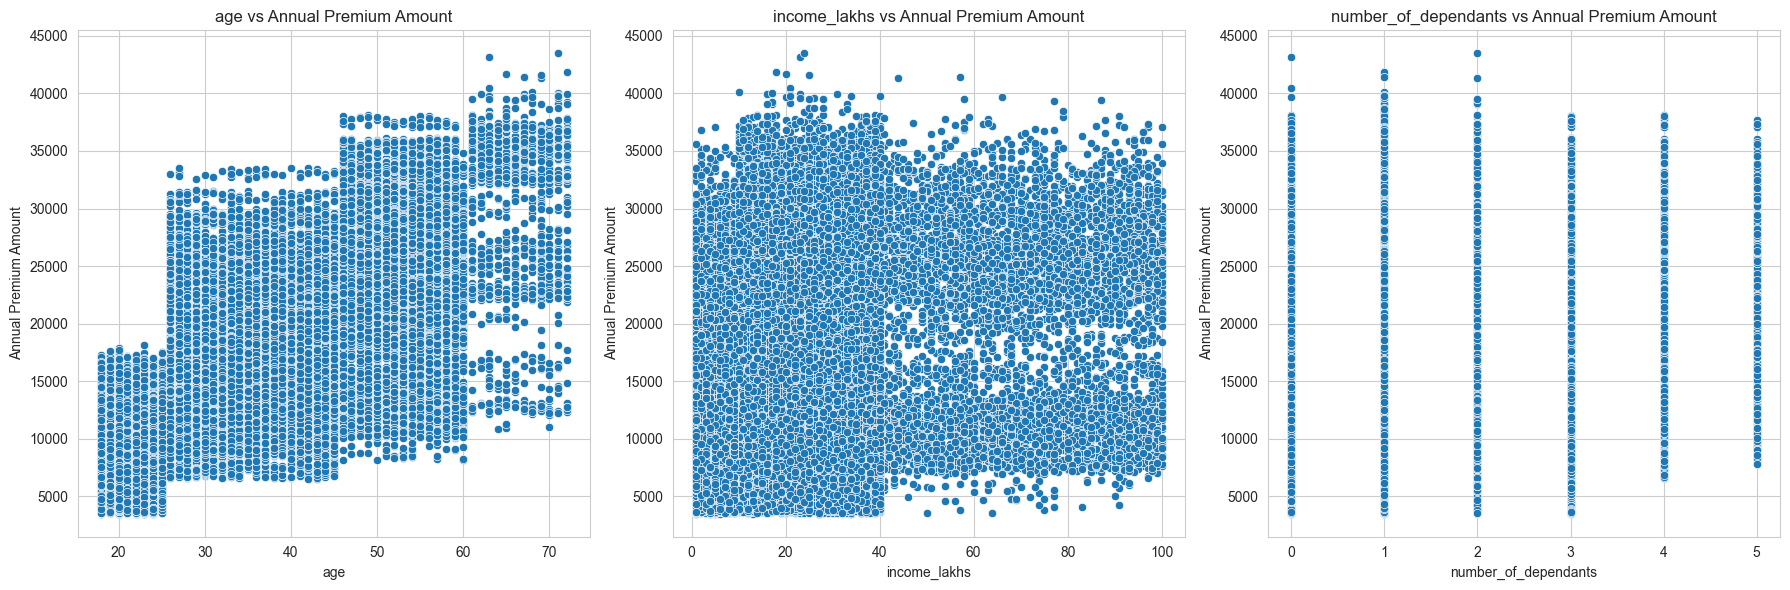

In [223]:
# Visualize the relationship between numerical features and the target variable
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(data=df2,x=column,y='annual_premium_amount',ax=ax)
    ax.set_title(f'{column} vs Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()
plt.show()

### **2. Categorical Columns**

In [224]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [225]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df2['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

#### **Univariate Analysis**

In [226]:
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [227]:
pct_count = df2['gender'].value_counts(normalize=True)*100

In [228]:
pct_count

gender
Male      54.963132
Female    45.036868
Name: proportion, dtype: float64

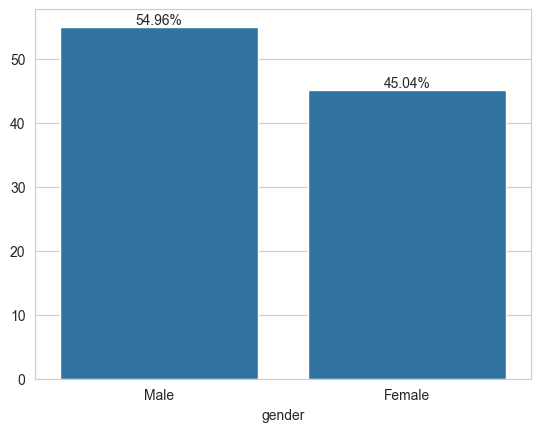

In [229]:
ax = sns.barplot(x=pct_count.index,y=pct_count.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.show()

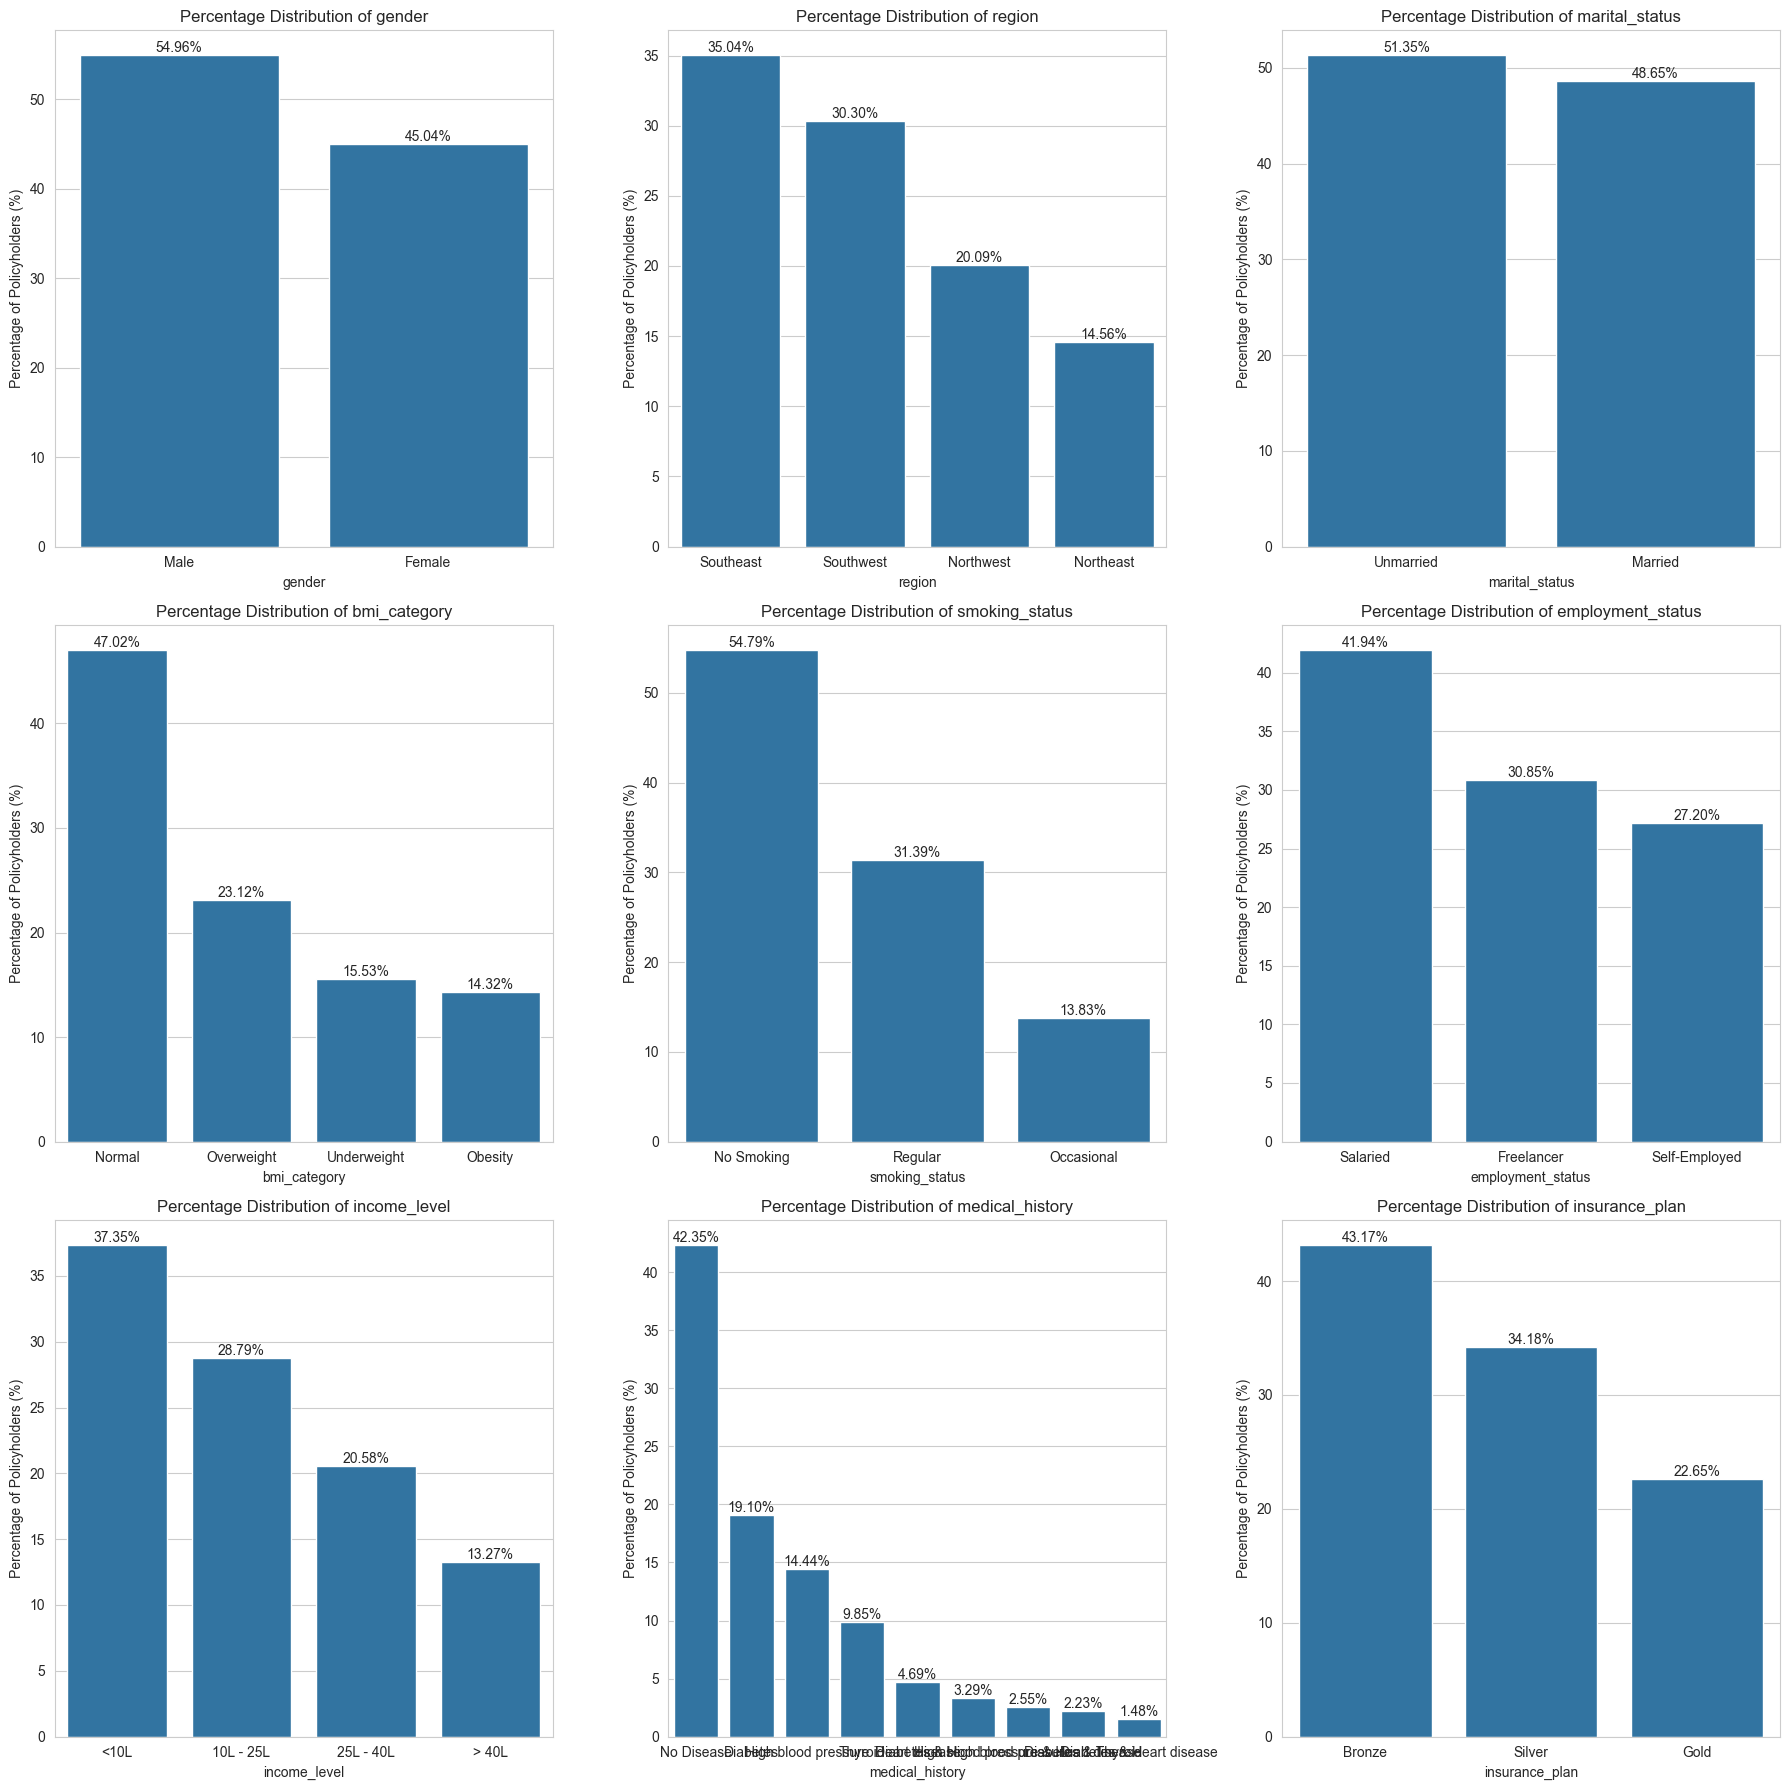

In [230]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for ax, column in zip(axes, categorical_cols):
    category_counts = df2[column].value_counts(normalize=True) * 100

    sns.barplot(
        x=category_counts.index,
        y=category_counts.values,
        ax=ax
    )

    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Percentage of Policyholders (%)')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

#### **Bivariate Analysis**

insurance_plan  Bronze  Gold  Silver  Total
income_level                               
10L - 25L         5307  3880    5182  14369
25L - 40L         3683  2840    3750  10273
<10L             12226   931    5486  18643
> 40L              329  3653    2641   6623


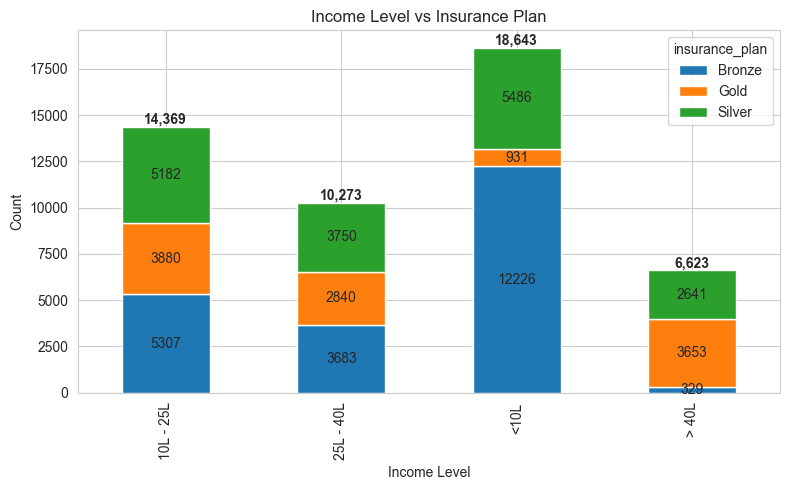

In [231]:
# Cross-tabulation of income level and insurance plan
crosstab = pd.crosstab(df2['income_level'],df2['insurance_plan'])

# Add row totals
crosstab['Total'] = crosstab.sum(axis=1)

print(crosstab)

# Plot stacked bar chart (excluding the Total column)
ax = crosstab.drop(columns='Total').plot(kind='bar',stacked=True,figsize=(8, 5))

ax.set_title('Income Level vs Insurance Plan')
ax.set_xlabel('Income Level')
ax.set_ylabel('Count')

# Add labels inside each stack
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# Add total count on top of each bar
for i, total in enumerate(crosstab['Total']):ax.text(i,total,f'{total:,}',ha='center',va='bottom',fontweight='bold')

plt.tight_layout()
plt.show()

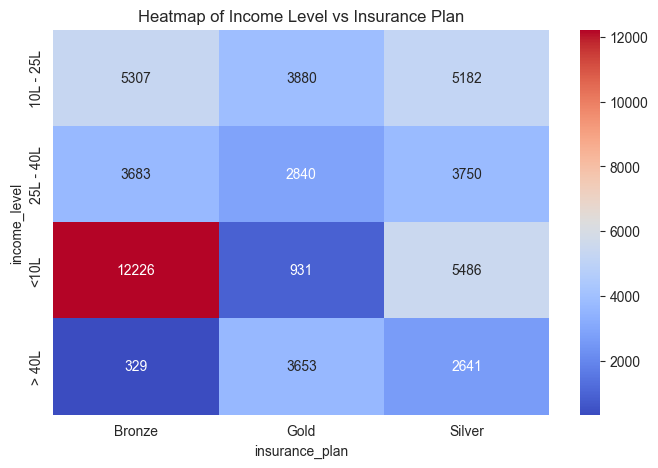

In [232]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    crosstab.drop(columns='Total'),
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title('Heatmap of Income Level vs Insurance Plan')
plt.show()

### **Feature Engineering**

In [233]:
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


#### **Calculate Risk Score**

In [234]:
# Define risk scores for medical conditions
risk_scores = {'diabetes': 6,'heart disease': 8,'high blood pressure': 6,'thyroid': 5,'no disease': 0,'none': 0}

# Split medical history into individual conditions
df2[['disease1', 'disease2']] = (df2['medical_history'].str.split(' & ', expand=True).apply(lambda col: col.str.lower()))

df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')

# Calculate total risk score
df2['total_risk_score'] = (df2['disease1'].map(risk_scores) +df2['disease2'].map(risk_scores))

# Normalize risk scores to the range [0, 1]
min_score = df2['total_risk_score'].min()
max_score = df2['total_risk_score'].max()

df2['normalized_risk_score'] = ((df2['total_risk_score'] - min_score) /(max_score - min_score))

df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571


#### **Encode Text Columns**

In [235]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [236]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [237]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [238]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

In [239]:
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [240]:
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1


In [241]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49908 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              49908 non-null  int64  
 1   number_of_dependants             49908 non-null  int64  
 2   income_level                     49908 non-null  int64  
 3   income_lakhs                     49908 non-null  int64  
 4   medical_history                  49908 non-null  object 
 5   insurance_plan                   49908 non-null  int64  
 6   annual_premium_amount            49908 non-null  int64  
 7   disease1                         49908 non-null  object 
 8   disease2                         49908 non-null  object 
 9   total_risk_score                 49908 non-null  int64  
 10  normalized_risk_score            49908 non-null  float64
 11  gender_Male                      49908 non-null  int64  
 12  region_Northwest       

#### **Feature Selection**

In [242]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)

In [243]:
df4.head(5)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


#### **Calculate VIF for Multicolinearity**

In [244]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

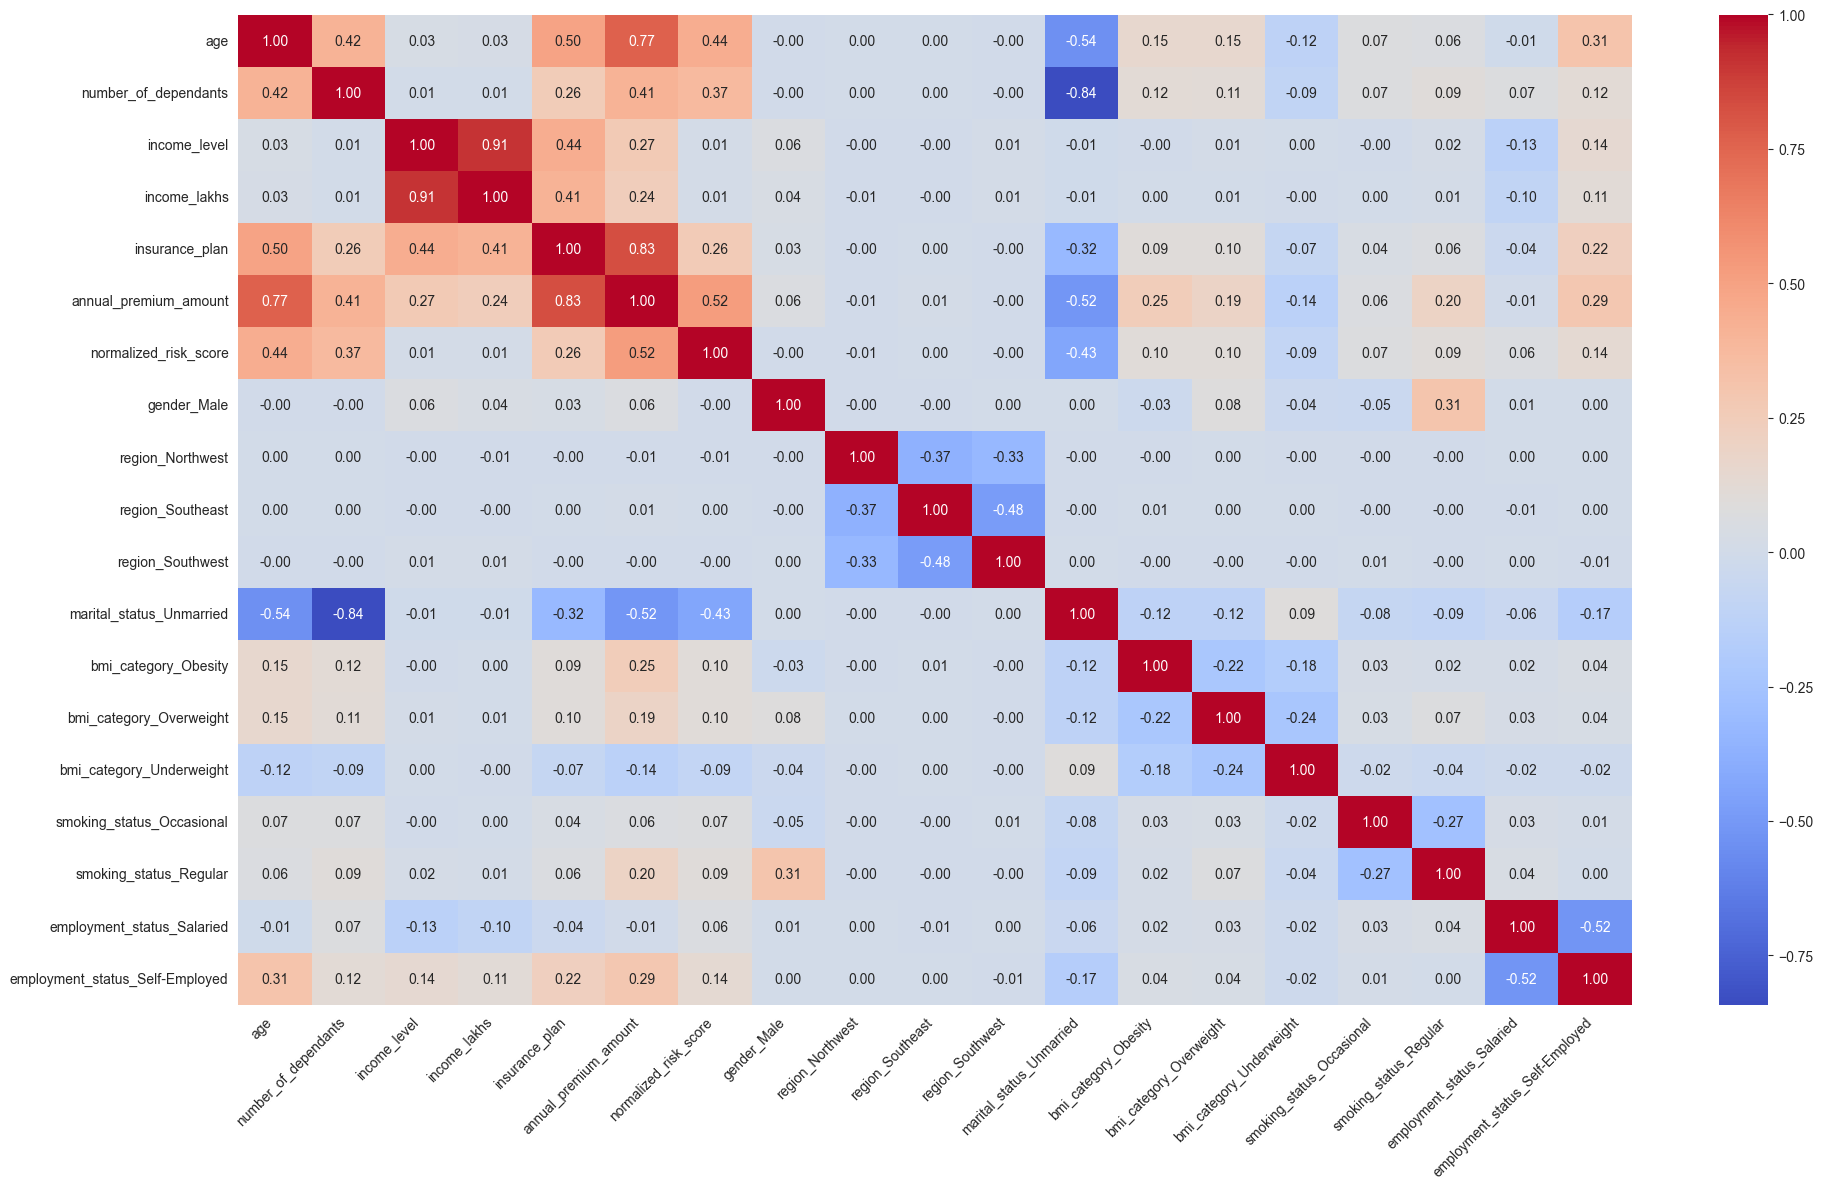

In [245]:
# Correlation matrix of numerical features
correlation_matrix = df4.corr()

plt.figure(figsize=(20, 12))

sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [246]:
# Separate features and target variable
X = df4.drop(columns='annual_premium_amount')
y = df4['annual_premium_amount']

# Scale numerical features using Min-Max scaling
from sklearn.preprocessing import MinMaxScaler

features_to_scale = ['age','number_of_dependants','income_level','income_lakhs','insurance_plan']

scaler = MinMaxScaler()

X[features_to_scale] = scaler.fit_transform(X[features_to_scale])

X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [247]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [248]:
calculate_vif(X)

,Column,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalized_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


In [249]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


In [250]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop('income_level', axis="columns")

### **Model Training**

In [251]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34935, 17)
x test:  (14973, 17)
y train:  (34935,)
y test:  (14973,)


#### **Linear Regression Model**

In [252]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9282143576916762, 0.9280547230217837)

In [253]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  5165611.913027984 RMSE:  2272.7982561212916


In [254]:
X_test.shape

(14973, 17)

In [255]:
np.set_printoptions(suppress=True, precision=6)

In [256]:
model_lr.coef_

array([11160.926462,  -676.443991,  -514.229816, 12557.012936,
        4810.357702,   168.646662,   -35.719292,    39.96513 ,
         -24.652929,  -935.760611,  3387.911455,  1599.362268,
         391.171304,   735.912278,  2234.804712,   155.984674,
         415.903973])

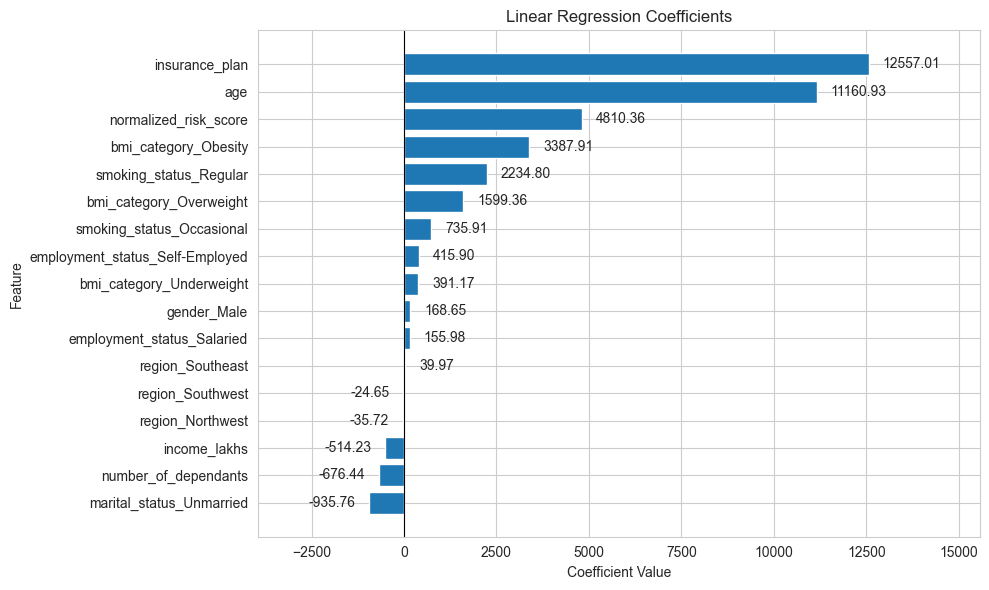

In [257]:
# Create a DataFrame of feature coefficients
coef_df = pd.DataFrame({'Feature': X_train.columns,'Coefficient': model_lr.coef_}).sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))

bars = plt.barh(coef_df['Feature'],coef_df['Coefficient'])

# Add coefficient labels
offset = coef_df['Coefficient'].abs().max() * 0.03

for bar in bars:
    width = bar.get_width()

    plt.text(width + offset if width > 0 else width - offset,bar.get_y() + bar.get_height() / 2,f'{width:.2f}',va='center',
        ha='left' if width > 0 else 'right')

# Add padding on both sides
xmin = coef_df['Coefficient'].min() - offset * 8
xmax = coef_df['Coefficient'].max() + offset * 8
plt.xlim(xmin, xmax)

plt.axvline(x=0, color='black', linewidth=0.8)

plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients')

plt.tight_layout()
plt.show()

#### **Ridge Regression Model**

In [258]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9282143198366275, 0.9280541644640345)

In [259]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  5165652.017016523 RMSE:  2272.8070787060924


#### **Random Forest**

In [260]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Train baseline model
model_rf = RandomForestRegressor(n_estimators=100,max_depth=3,random_state=42)

model_rf.fit(X_train, y_train)
model_rf.score(X_test, y_test)

0.9127735156062056

In [261]:
# Predictions and evaluation
y_pred = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Regression ==> MSE:", mse_rf, "RMSE:", rmse_rf)

Random Forest Regression ==> MSE: 6262790.079362137 RMSE: 2502.5567085207354


In [262]:
# Hyperparameter tuning
model_rf = RandomForestRegressor(random_state=42)

param_grid = {'n_estimators': [100, 200, 300],'max_depth': [3, 5, 10, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

random_search = RandomizedSearchCV(estimator=model_rf,param_distributions=param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

random_search.best_score_

np.float64(0.9811026296098978)

In [263]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_depth': 10}

In [264]:
best_model = random_search.best_estimator_

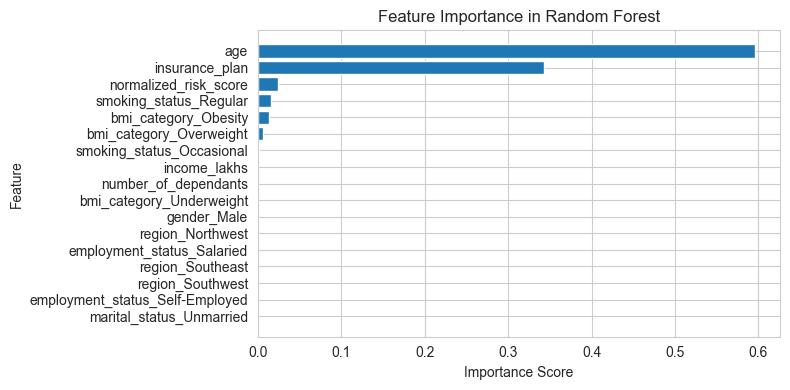

In [265]:
# Feature importance
feature_importance = best_model.feature_importances_

importance_df = pd.DataFrame({'Feature': X_train.columns,'Importance': feature_importance}).sort_values(by='Importance')

plt.figure(figsize=(8, 4))

plt.barh(importance_df['Feature'],importance_df['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest')

plt.tight_layout()
plt.show()

#### **Error Analysis**

In [266]:
# Generate predictions using the best Random Forest model
y_pred = best_model.predict(X_test)

# Calculate prediction errors
residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

# Create a results DataFrame
results_df = pd.DataFrame({'actual': y_test,'predicted': y_pred,'diff': residuals,'diff_pct': residuals_pct})

results_df.head()

,actual,predicted,diff,diff_pct
3598,20554,20545.330290,-8.669710,-0.042180
35794,29647,29367.517657,-279.482343,-0.942700
43608,20560,20388.827215,-171.172785,-0.832552
42730,5018,6943.296077,1925.296077,38.367797
18936,8929,8242.899938,-686.100062,-7.683952


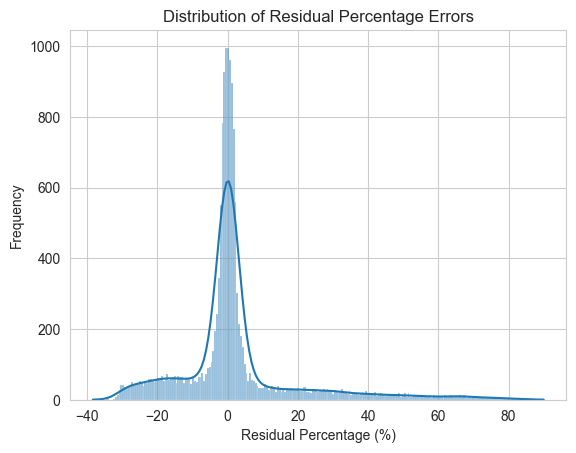

In [267]:
sns.histplot(results_df['diff_pct'], kde=True)

plt.title('Distribution of Residual Percentage Errors')
plt.xlabel('Residual Percentage (%)')
plt.ylabel('Frequency')

plt.savefig("../images/full_data_analysis_residual_errors.png", dpi=300, bbox_inches="tight")
plt.show()

In [268]:
X_test.shape

(14973, 17)

In [269]:
# Identify predictions with large percentage errors
error_threshold = 10

extreme_results_df = results_df[
    np.abs(results_df['diff_pct']) > error_threshold]

extreme_results_df.head()

,actual,predicted,diff,diff_pct
42730,5018,6943.296077,1925.296077,38.367797
20029,5140,6529.634095,1389.634095,27.035683
4294,9631,6749.106620,-2881.893380,-29.923096
44419,4687,6592.062324,1905.062324,40.645665
6707,8826,10055.392013,1229.392013,13.929209


In [270]:
extreme_results_df.shape

(4421, 4)

In [271]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]

In [272]:
extreme_errors_pct

29.52648099913177

We observe that approximately **30% of customers** have extreme prediction errors, meaning the model may either overcharge or undercharge premiums by **10% or more** for these customers.

In [273]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
36269,3501,6652.388522,3151.388522,90.013954
18807,3569,6668.246982,3099.246982,86.837965
9118,3536,6567.148403,3031.148403,85.722523
18564,3523,6532.291084,3009.291084,85.418424
37275,3570,6617.031547,3047.031547,85.351024
...,...,...,...,...
29843,4283,6434.492018,2151.492018,50.233295
3703,4444,6675.154390,2231.154390,50.205994
41423,4738,7113.285981,2375.285981,50.132672
44377,4643,6970.572561,2327.572561,50.130790


Approximately **519 customers** may be overcharged or undercharged by **more than 50%** based on the model's predictions.

In [274]:
# Retrieve feature values for observations with extreme prediction errors
extreme_errors_df = X_test.loc[extreme_results_df.index]

In [275]:
extreme_errors_df.head(5)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
42730,0.092593,0.2,0.131313,0.0,0.428571,1,0,0,0,1,0,1,0,0,0,0,0
20029,0.018519,0.2,0.030303,0.0,0.000000,0,1,0,0,1,0,0,1,0,0,1,0
4294,0.000000,0.2,0.020202,0.0,0.000000,1,0,0,1,1,0,1,0,0,0,0,0
44419,0.055556,0.0,0.242424,0.0,0.000000,0,0,0,0,1,0,0,1,0,0,0,0
6707,0.111111,0.2,0.070707,0.5,0.000000,1,0,0,0,1,0,0,1,0,0,0,0


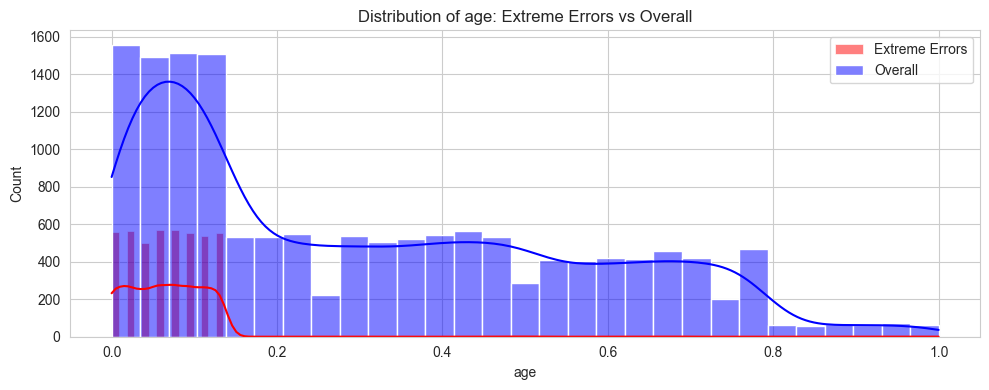

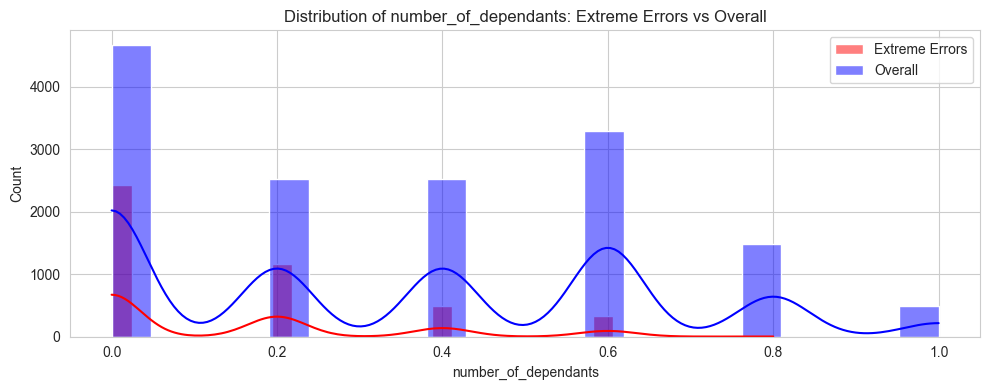

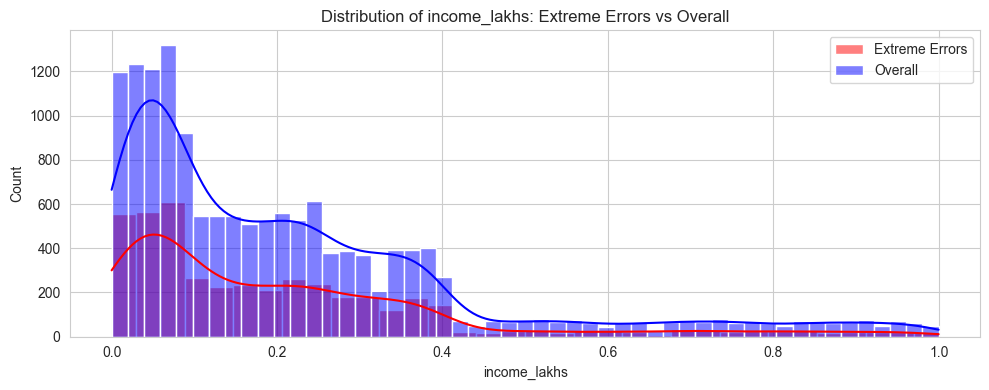

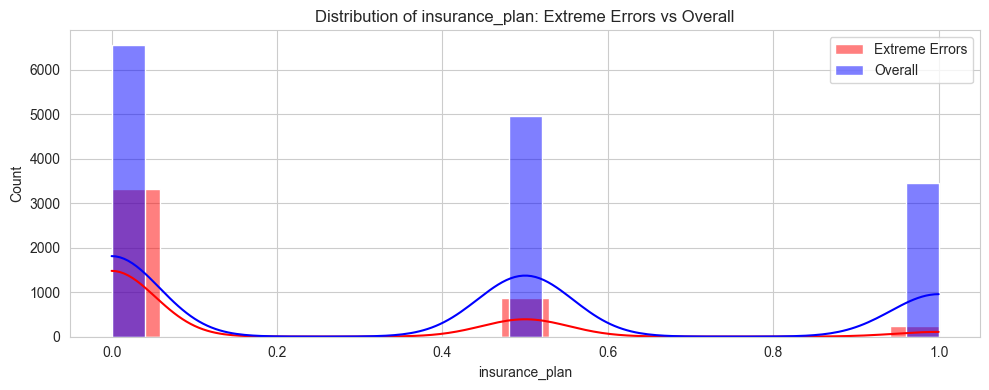

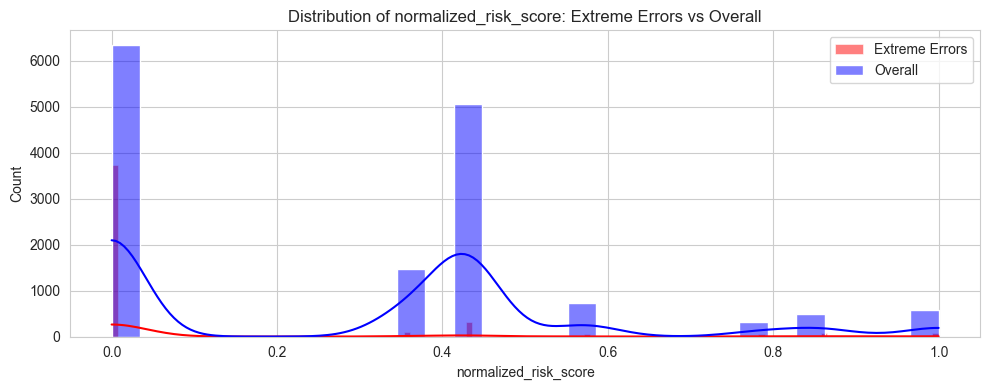

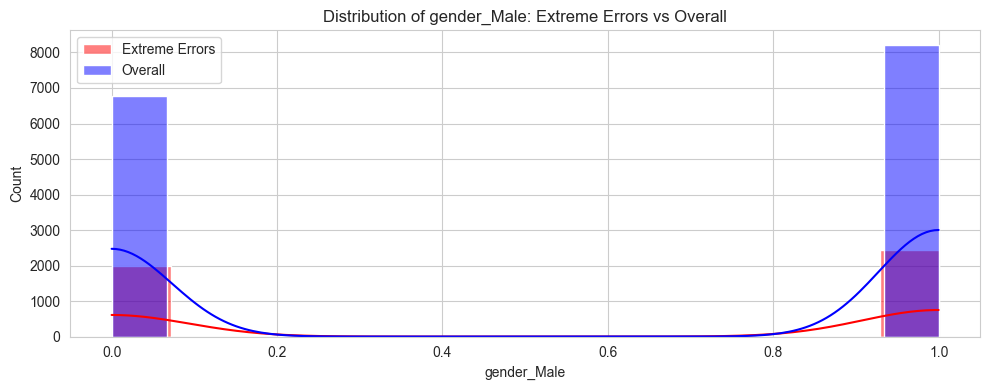

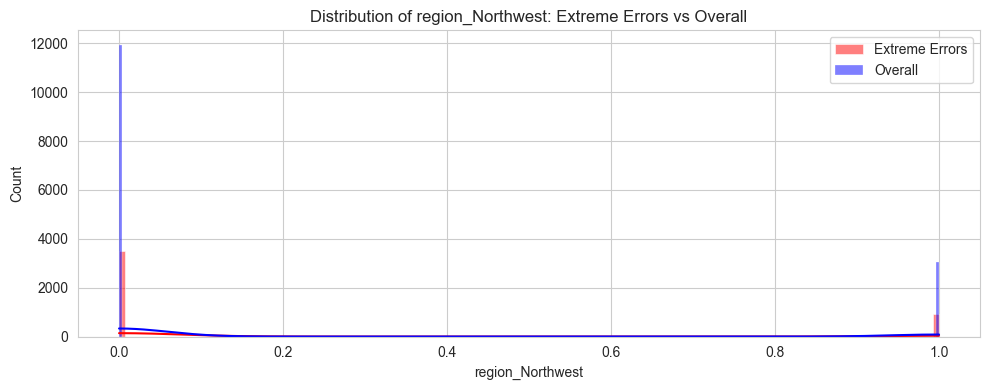

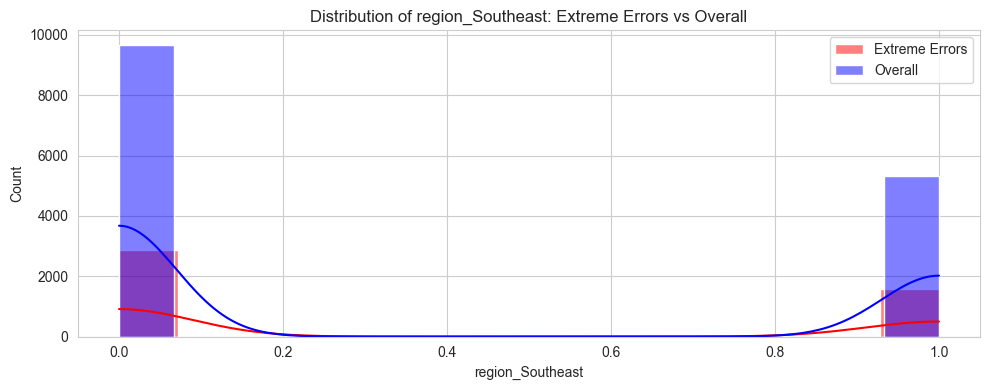

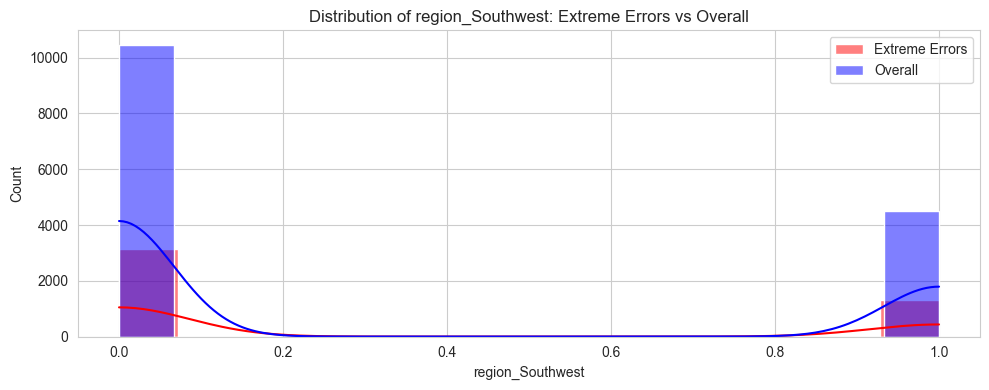

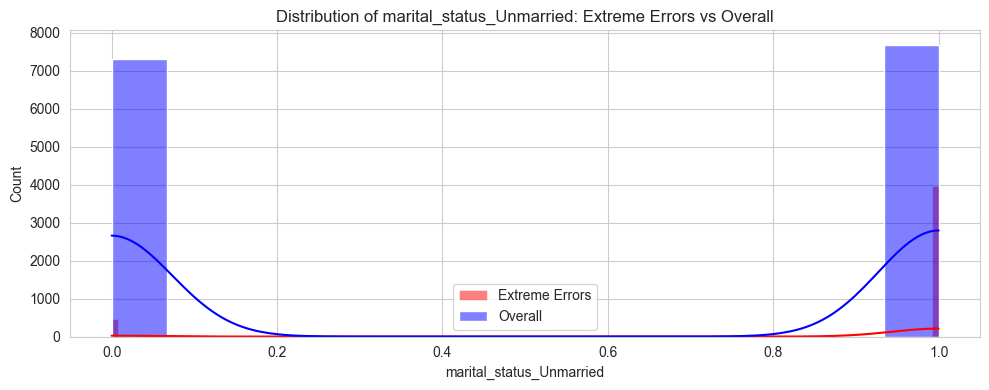

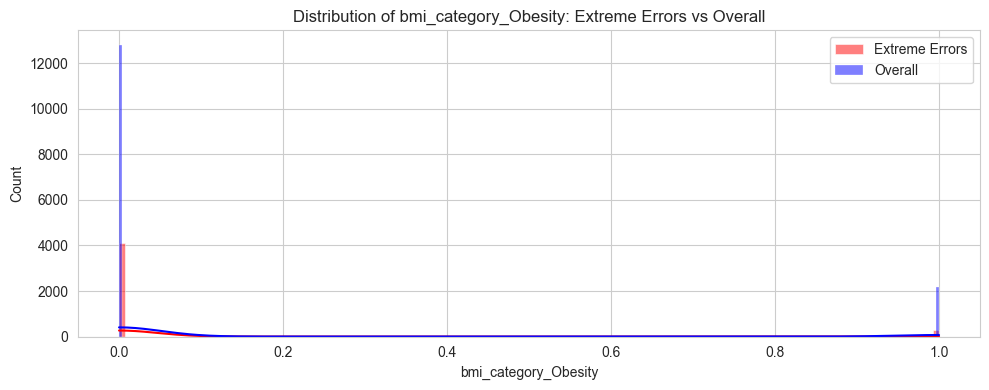

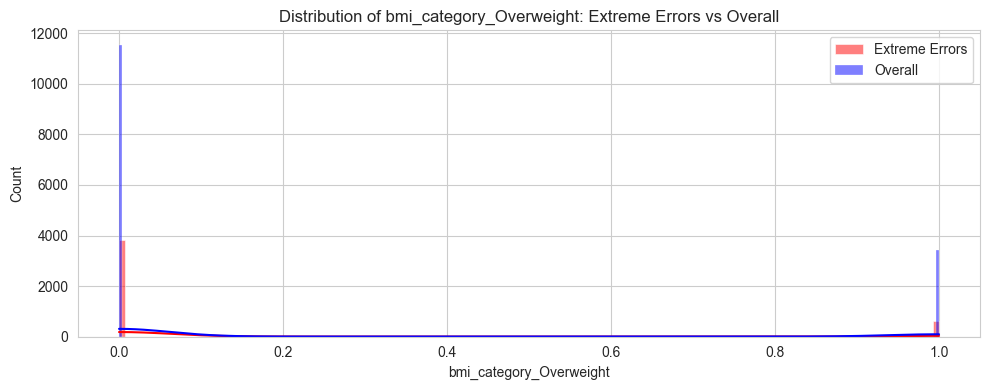

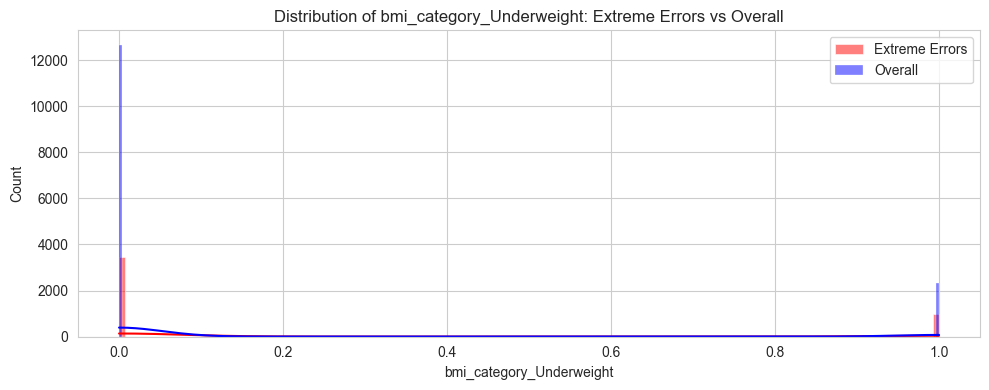

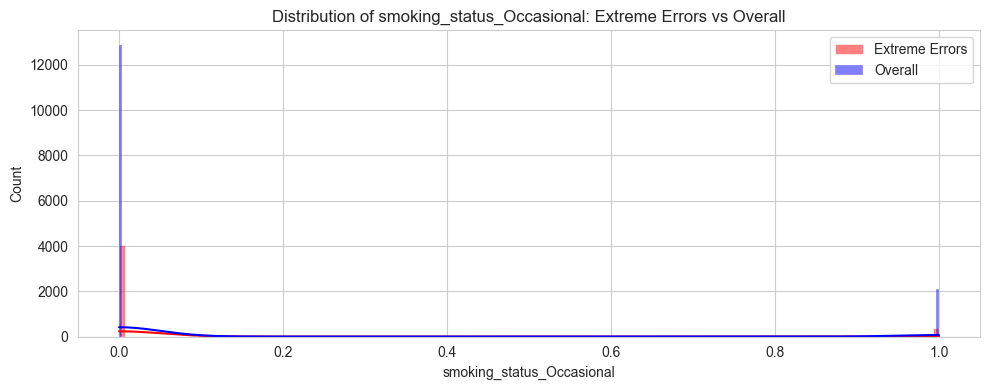

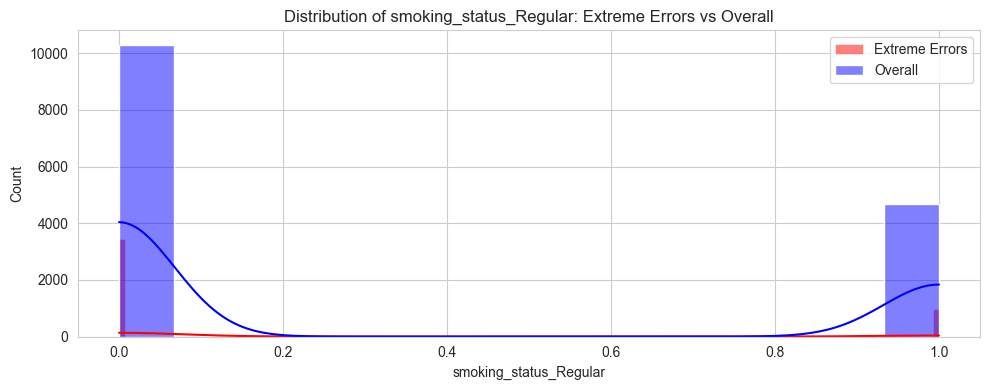

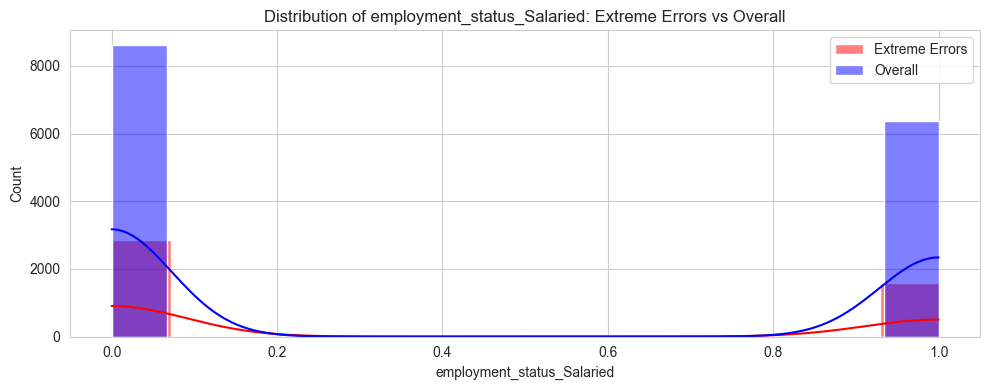

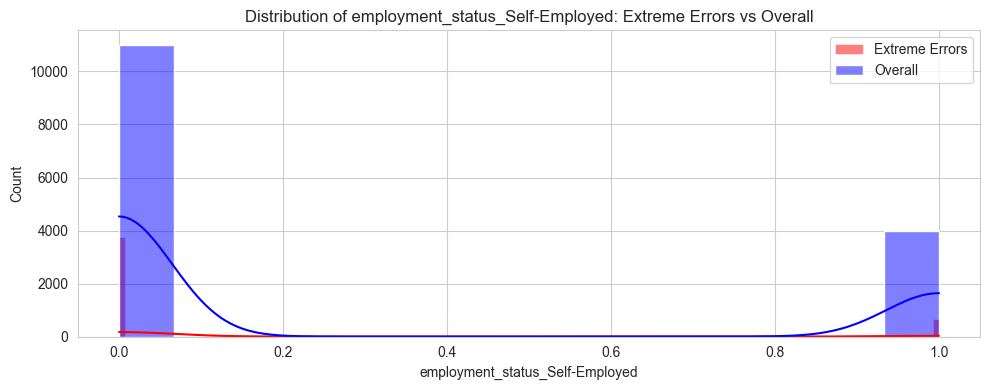

In [276]:
# Compare feature distributions for extreme-error cases versus the overall test set
for feature in X_test.columns:

    plt.figure(figsize=(10, 4))

    sns.histplot(extreme_errors_df[feature],color='red',label='Extreme Errors',kde=True)

    sns.histplot(X_test[feature],color='blue',label='Overall',alpha=0.5,kde=True)

    plt.title(f'Distribution of {feature}: Extreme Errors vs Overall')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()

    plt.tight_layout()
    plt.show()

### **Reverse Scaling**

In [277]:
extreme_errors_df['income_level']=-1

In [278]:
df_reversed = pd.DataFrame()
df_reversed[features_to_scale] = scaler.inverse_transform(extreme_errors_df[features_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,23.0,1.0,-2.0,14.0,1.0
1,19.0,1.0,-2.0,4.0,1.0
2,18.0,1.0,-2.0,3.0,1.0
3,21.0,0.0,-2.0,25.0,1.0
4,24.0,1.0,-2.0,8.0,2.0


In [279]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4421.000000,4421.000000,4421.0,4421.000000,4421.000000
mean,21.609138,0.712056,-2.0,21.405112,1.304004
std,3.054949,0.940594,0.0,20.725580,0.564288
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,19.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,15.000000,1.000000
75%,23.000000,1.000000,-2.0,30.000000,2.000000
max,72.000000,4.000000,-2.0,100.000000,3.000000


<Axes: xlabel='age', ylabel='Count'>

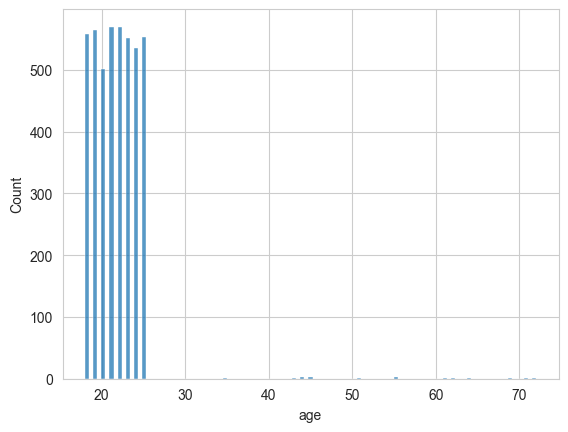

In [280]:
sns.histplot(df_reversed.age)

In [281]:
df_reversed['age'].quantile(0.99)

np.float64(25.0)

Most extreme prediction errors are concentrated among customers below 25 years of age, indicating that a separate model for this segment may help improve prediction accuracy.